##  **STUDENT PERFORMANCE ANALYZER**

Many students have different study habits, study hours, extracurricular activities, attendance etc. These all factors contribute differently to student's total grade. This project will analyze every factor for a student, and make a model to predict their marks based on their study habits and performance. 

### **INTRODUCTION** 

This project analyzes student study habits and academic performance using data analysis and machine learning. The dataset we have contains information such as student ID, gender, attendance, and study hours. We will explore the relationships between these factors and student marks, and use Linear Regression to predict academic performance.

### **LOADING DATASET** 

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
#into pandas DataFrame
df=pd.read_csv(r"C:\Users\DELL\Downloads\archive\student_performance_dataset.csv")

### **UNDERSTANDING DATA** 

In [48]:
df.head()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   object 
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    object 
 6   internet_access             1000 non-null   object 
 7   extracurricular_activities  1000 non-null   object 
 8   part_time_job               1000 non-null   object 
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   object 
dtypes: float64(5), int64(1), object(6)
memory usage: 93.9+ KB


In [50]:
#to check null values 
df.isnull().sum()

student_id                      0
gender                          0
study_time_hours                0
attendance_percent              0
sleep_hours                     0
parental_education            102
internet_access                 0
extracurricular_activities      0
part_time_job                   0
previous_grade                  0
final_exam_score                0
final_grade                     0
dtype: int64

In [51]:
#cleaning dataset
#student id= a series of numbers, final grade= potential leakage to final exam score
df= df.drop(["student_id","final_grade"], axis=1)

In [52]:
#filling 102 empty enteries with keyword
df["parental_education"] = df["parental_education"].fillna("unknown")

In [53]:
df.head()

,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score
0,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0
1,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0
2,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3
3,Male,2.6,77.5,8.0,unknown,Yes,Yes,No,85.1,83.8
4,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3


In [54]:
#to check if we have any duplicated rows
df.duplicated().sum()

0

### **DETECTING OUTLIERS** 

<Axes: xlabel='study_time_hours'>

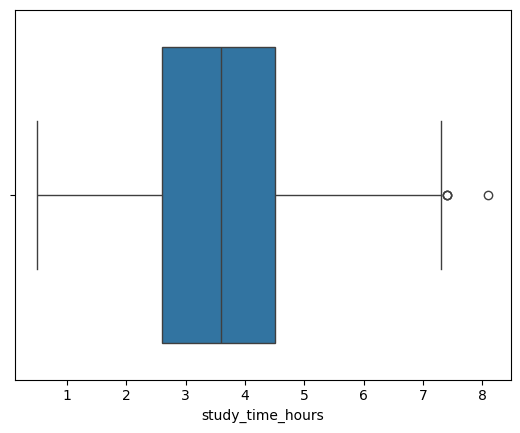

In [55]:
#to check outliers
sns.boxplot(x=df["study_time_hours"])

In [56]:
df["study_time_hours"].describe()

count    1000.000000
mean        3.570700
std         1.478559
min         0.500000
25%         2.600000
50%         3.600000
75%         4.500000
max         8.100000
Name: study_time_hours, dtype: float64

<Axes: xlabel='attendance_percent'>

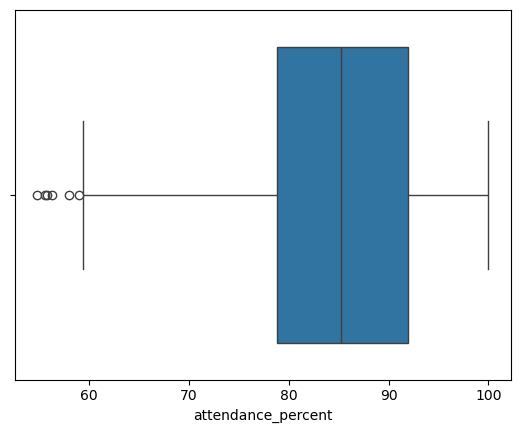

In [57]:
sns.boxplot(x=df["attendance_percent"])

In [58]:
df["attendance_percent"].describe()

count    1000.000000
mean       85.092300
std         9.270685
min        54.800000
25%        78.800000
50%        85.200000
75%        91.900000
max       100.000000
Name: attendance_percent, dtype: float64

<Axes: xlabel='sleep_hours'>

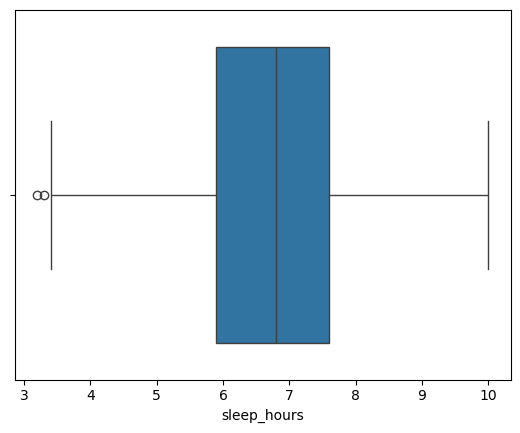

In [59]:
sns.boxplot(x=df["sleep_hours"])

In [60]:
df["sleep_hours"].describe()

count    1000.000000
mean        6.799500
std         1.203527
min         3.200000
25%         5.900000
50%         6.800000
75%         7.600000
max        10.000000
Name: sleep_hours, dtype: float64

<Axes: xlabel='previous_grade'>

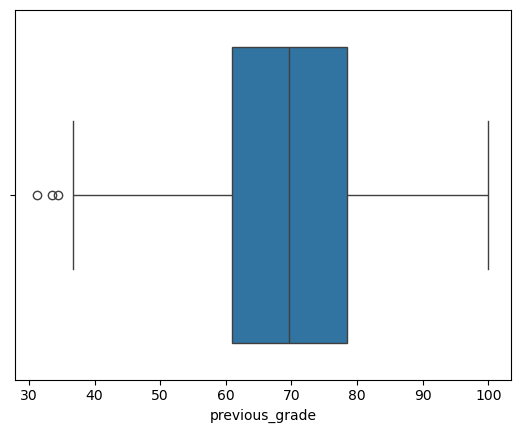

In [61]:
sns.boxplot(x=df["previous_grade"])

In [62]:
df["previous_grade"].describe()

count    1000.000000
mean       69.740900
std        12.613425
min        31.300000
25%        61.000000
50%        69.600000
75%        78.400000
max       100.000000
Name: previous_grade, dtype: float64

<Axes: xlabel='final_exam_score'>

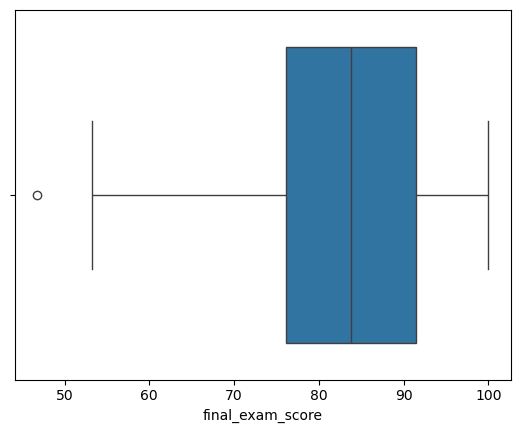

In [63]:
sns.boxplot(x=df["final_exam_score"])

In [64]:
df["final_exam_score"].describe()

count    1000.000000
mean       83.543500
std        10.341333
min        46.800000
25%        76.075000
50%        83.800000
75%        91.525000
max       100.000000
Name: final_exam_score, dtype: float64

### **UNIVARIATE ANALYSIS** 

In [65]:
df["gender"].value_counts()

gender
Female    510
Male      490
Name: count, dtype: int64

In [66]:
df["parental_education"].value_counts()

parental_education
High School    356
Bachelors      308
Masters        184
unknown        102
PhD             50
Name: count, dtype: int64

In [67]:
df["internet_access"].value_counts()

internet_access
Yes    854
No     146
Name: count, dtype: int64

In [68]:
df["extracurricular_activities"].value_counts()

extracurricular_activities
Yes    572
No     428
Name: count, dtype: int64

In [69]:
df["part_time_job"].value_counts()

part_time_job
No     684
Yes    316
Name: count, dtype: int64

### **BIVARIATE ANALYSIS: NUMERICAL VS TARGET VARIABLE** 

<Axes: >

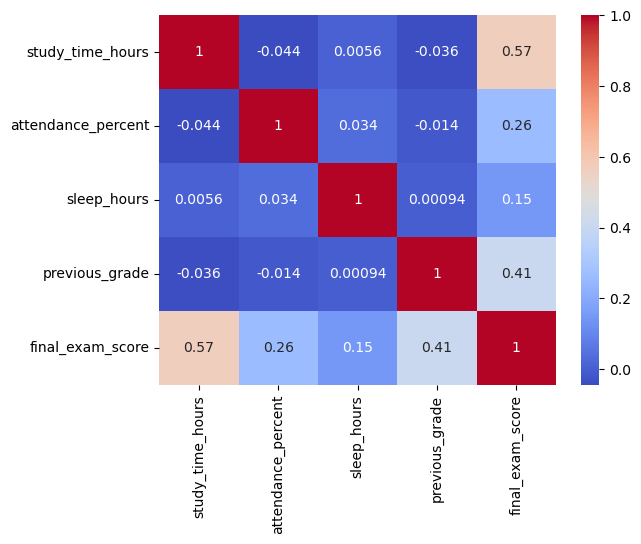

In [70]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

### **BIVARIATE ANALYSIS: CATEGORICAL VS TARGET VARIABLE** 

<Axes: xlabel='gender', ylabel='final_exam_score'>

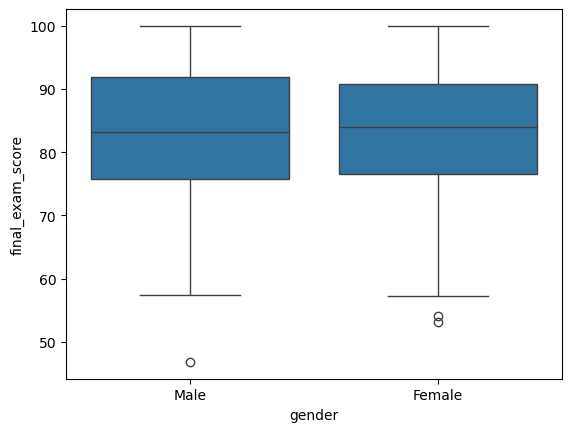

In [71]:
sns.boxplot(x="gender", y="final_exam_score", data=df)
#the boxplot shows almost similar distrbution of male and female students also low score outliers are present in both groups

<Axes: xlabel='parental_education', ylabel='final_exam_score'>

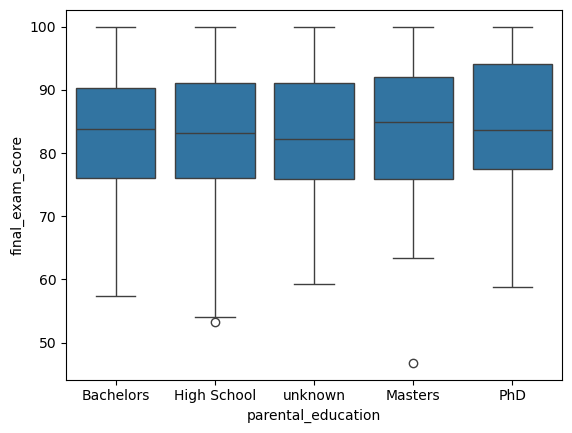

In [72]:
sns.boxplot(x="parental_education", y="final_exam_score", data=df)
#we have nearly similar distribution of parental education

<Axes: xlabel='internet_access', ylabel='final_exam_score'>

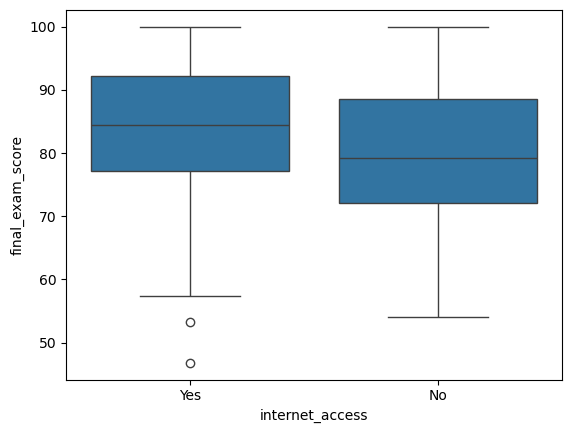

In [73]:
sns.boxplot(x="internet_access", y="final_exam_score", data=df)
#internet access shows typically greater difference in our boxplot

<Axes: xlabel='extracurricular_activities', ylabel='final_exam_score'>

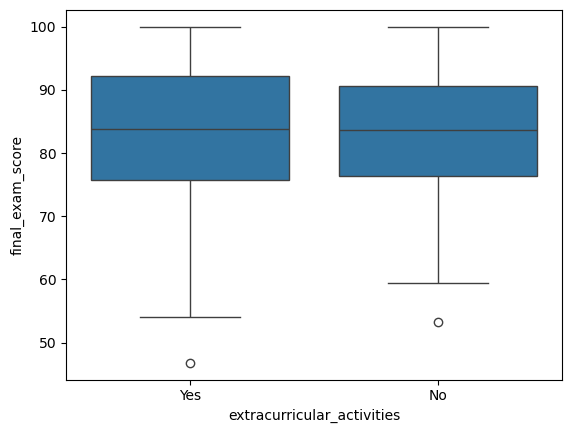

In [74]:
sns.boxplot(x="extracurricular_activities", y="final_exam_score", data=df)
#almost equally distributed

<Axes: xlabel='part_time_job', ylabel='final_exam_score'>

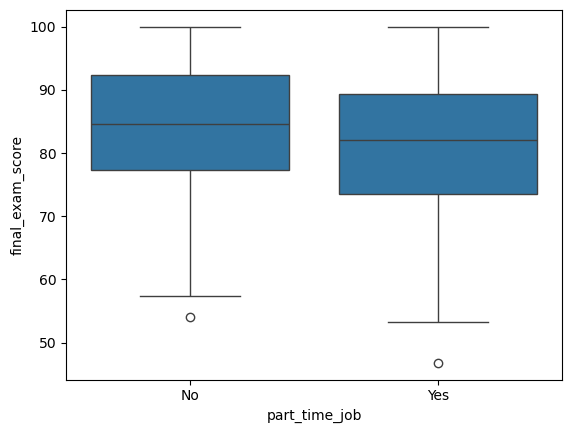

In [75]:
sns.boxplot(x="part_time_job", y="final_exam_score", data=df)

### **FEATURE SELECTION** 

In [76]:
#performing one-hot encoding on internet_access column
df= pd.get_dummies(df, columns=["internet_access","part_time_job"], drop_first= True)

In [77]:
df.columns

Index(['gender', 'study_time_hours', 'attendance_percent', 'sleep_hours',
       'parental_education', 'extracurricular_activities', 'previous_grade',
       'final_exam_score', 'internet_access_Yes', 'part_time_job_Yes'],
      dtype='object')

In [78]:
selected_features = [
    "study_time_hours",
    "attendance_percent",
    "internet_access_Yes",
    "previous_grade",
    "part_time_job_Yes"
]
target= "final_exam_score"

In [79]:
df_final= df[selected_features + [target]]

In [80]:
df_final.head()

,study_time_hours,attendance_percent,internet_access_Yes,previous_grade,part_time_job_Yes,final_exam_score
0,4.0,98.0,True,76.9,False,100.0
1,6.3,100.0,True,75.5,True,100.0
2,4.9,85.3,True,88.5,True,97.3
3,2.6,77.5,True,85.1,False,83.8
4,2.2,89.6,True,61.8,True,68.3


In [81]:
df_final.tail()

,study_time_hours,attendance_percent,internet_access_Yes,previous_grade,part_time_job_Yes,final_exam_score
995,2.8,75.4,True,60.5,False,70.7
996,6.7,88.4,False,82.2,False,99.5
997,2.6,84.5,True,65.2,True,79.2
998,4.6,85.3,False,52.2,True,82.2
999,3.9,77.4,True,45.4,False,70.4


In [82]:
x = df_final[selected_features]
y = df_final[target]

### **TRAIN-TEST SPLIT** 

In [83]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test= train_test_split(x, y, test_size= 0.2, random_state= 10)

In [84]:
x_train.shape

(800, 5)

In [85]:
x_test.shape

(200, 5)

In [86]:
y_train.shape

(800,)

In [87]:
y_test.shape

(200,)

### **LINEAR-REGRESSION MODEL** 

In [88]:
from sklearn.linear_model import LinearRegression
model= LinearRegression()

In [89]:
model.fit(x_train, y_train)

LinearRegression()

In [90]:
prediction_y = model.predict(x_test)

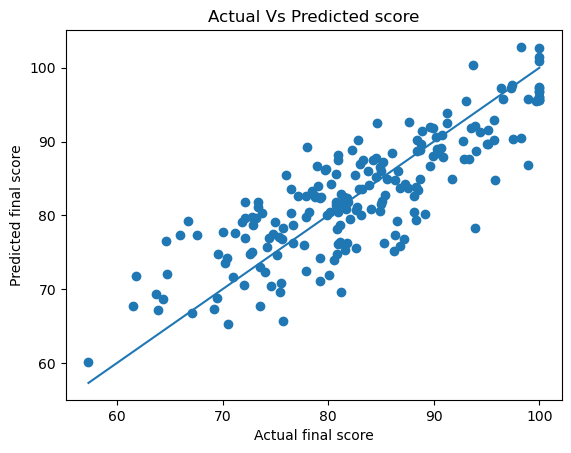

In [91]:
#plottting graph for actual test values and predicted values
import matplotlib.pyplot as plt
plt.scatter(y_test, prediction_y)
plt.xlabel("Actual final score")
plt.ylabel("Predicted final score")
plt.title("Actual Vs Predicted score")
plt.plot([y_test.min(),y_test.max()], [y_test.min(), y_test.max()])  #perfect line

### **EVALUATING THE MODEL** 

In [92]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae= mean_absolute_error(y_test, prediction_y)
mse= mean_squared_error(y_test, prediction_y)
rmse= np.sqrt(mse)
r2= r2_score(y_test, prediction_y)

In [93]:
#average absolute difference between actual and predicted score
mae

4.242650461932466

In [94]:
mse

27.55700051515276

In [95]:
rmse

5.249476213409559

In [96]:
r2

0.6940817105087991

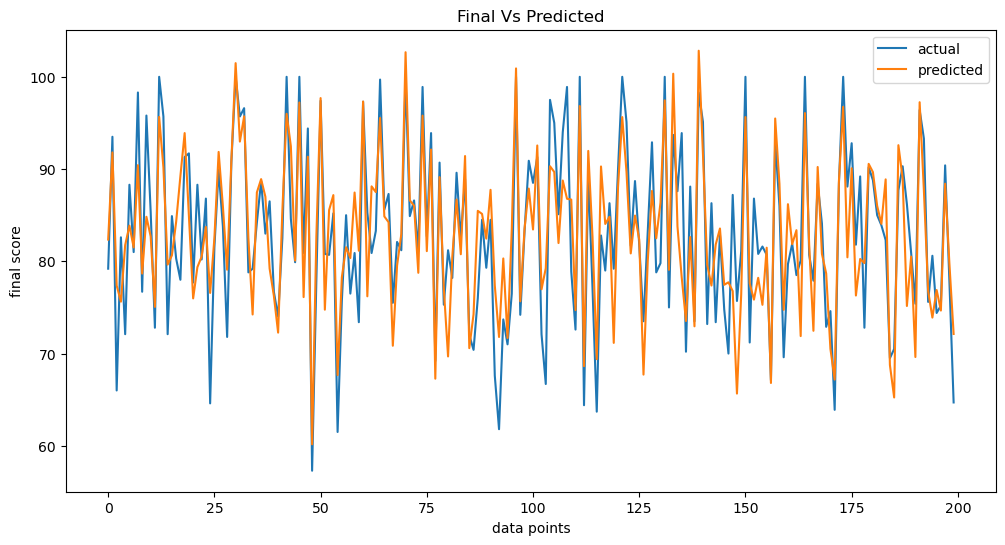

In [97]:
plt.figure(figsize= (12,6))
plt.plot(y_test.values, label="actual")
plt.plot(prediction_y, label="predicted")
plt.xlabel("data points")
plt.ylabel("final score")
plt.title("Final Vs Predicted")
plt.legend()